In [40]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms

import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split

import torch.optim as optim
import torch.ao.quantization as quant
import pytorch_lightning as pl
from torchvision.models import resnet18

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import os
import sys

from src.spectogram_datamodule import SpektogramDataModule

FOLDER_PATH = Path(r"spectogram_wieliczka")
TEST_FOLDER_PATH = Path(r"spectogram_ziemowit")
NUM_CLASSES = 2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


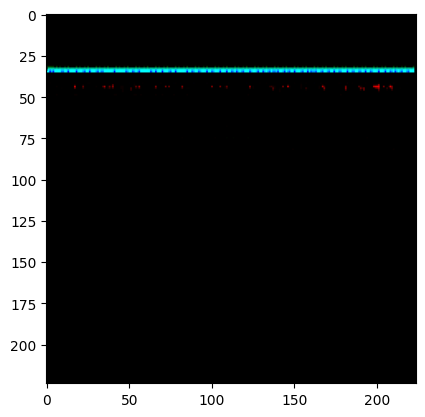

In [42]:
spectrogram_transforms = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224, 224)), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

dm_wieliczka = SpektogramDataModule(FOLDER_PATH, spectrogram_transforms)
dm_wieliczka.setup()

dm_ziemowit = SpektogramDataModule(TEST_FOLDER_PATH, spectrogram_transforms, test_split=1)
dm_ziemowit.setup()


plt.imshow(next(iter(dm_wieliczka.train_dataloader()))[0][3].numpy().transpose(1, 2, 0))

In [24]:
class LitResNet(pl.LightningModule):
	def __init__(self, num_classes=10, qat=False, lr=1e-3):
		super().__init__()
		self.save_hyperparameters()
		self.qat = qat
		self.lr = lr

		# ResNet18
		self.model = resnet18(pretrained=False, num_classes=num_classes)
		self.criterion = nn.CrossEntropyLoss()

		if self.qat:
			# Fuse modules
			self.model.eval()
			quant.fuse_modules(self.model, [['conv1','bn1','relu']], inplace=True)
			
			# Prepare QAT
			self.model.train()
			self.model.qconfig = quant.get_default_qat_qconfig("fbgemm")
			quant.prepare_qat(self.model, inplace=True)

			

		self.train_loss_history = []
		self.train_acc_history = []
		self.val_loss_history = []
		self.val_acc_history = []

	def forward(self, x):
		return self.model(x)


	def training_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
		self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True)
		return loss

	def validation_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		self.train_loss_history.append(loss.detach().cpu())
		self.train_acc_history.append(acc.detach().cpu())
		self.log("val_loss", loss, on_epoch=True, prog_bar=True)
		self.log("val_acc", acc, on_epoch=True, prog_bar=True)
		return loss

	def test_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		self.train_loss_history.append(loss.detach().cpu())
		self.train_acc_history.append(acc.detach().cpu())
		self.log("test_loss", loss, on_epoch=True, prog_bar=True)
		self.log("test_acc", acc, on_epoch=True, prog_bar=True)
		return loss

	def configure_optimizers(self):
		return optim.SGD(self.parameters(), lr=self.lr, momentum=0.9)

	def convert_to_int8(self):
		"""
		Zamienia QAT model na prawdziwy INT8 (po treningu)
		"""
		if self.qat:
			self.model.eval()
			self.model = quant.convert(self.model)
			print("Model zamieniony na INT8")

In [ ]:
model = LitResNet(num_classes=NUM_CLASSES, qat=False, lr=1e-3)


trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu",
)

trainer.fit(model, dm_wieliczka)

torch.save(model.state_dict(), "fp32_model.pth")

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode 
-------------------------------

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 19: 100%|██████████| 5/5 [00:00<00:00,  6.10it/s, v_num=11, train_loss_step=0.0105, train_acc_step=1.000, val_loss=0.00806, val_acc=1.000, train_loss_epoch=0.0124, train_acc_epoch=1.000]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 5/5 [00:01<00:00,  4.78it/s, v_num=11, train_loss_step=0.0105, train_acc_step=1.000, val_loss=0.00806, val_acc=1.000, train_loss_epoch=0.0124, train_acc_epoch=1.000]


In [ ]:
model = LitResNet(num_classes=NUM_CLASSES, qat=False, lr=1e-3)


trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu",
)

trainer.fit(model, dm_wieliczka)

42.63892364501953

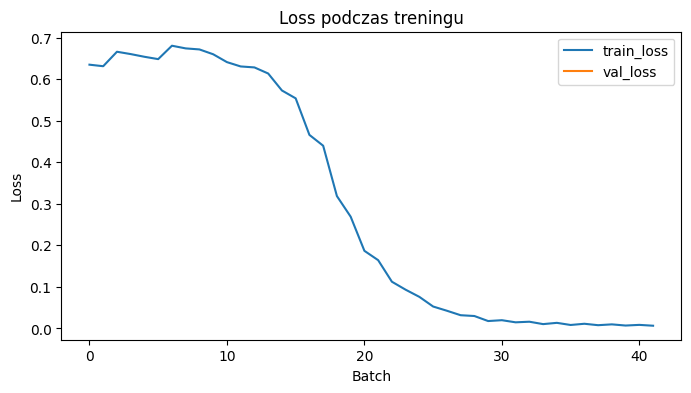

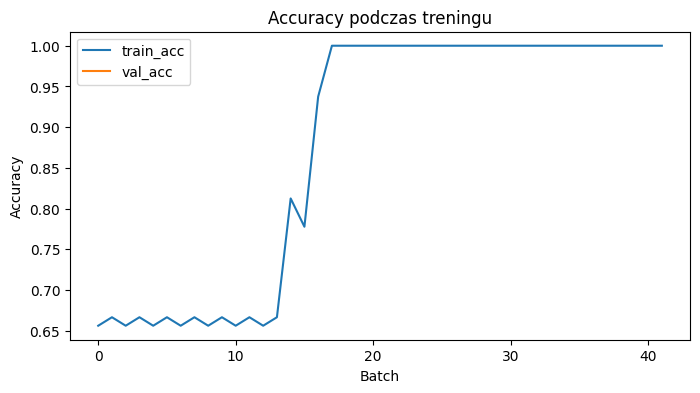

In [28]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,4))
plt.plot(model.train_loss_history, label="train_loss")
plt.plot(model.val_loss_history, label="val_loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Loss podczas treningu")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,4))
plt.plot(model.train_acc_history, label="train_acc")
plt.plot(model.val_acc_history, label="val_acc")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Accuracy podczas treningu")
plt.legend()
plt.show()


In [46]:
model = LitResNet(num_classes=NUM_CLASSES, qat=True, lr=1e-3)


trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu",
)

trainer.fit(model, dm_wieliczka)

model.convert_to_int8()

torch.save(model.state_dict(), "int8_model.pth")

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torch/ao/quantization/observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs au

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 19: 100%|██████████| 5/5 [00:01<00:00,  4.59it/s, v_num=14, train_loss_step=0.0705, train_acc_step=1.000, val_loss=0.113, val_acc=1.000, train_loss_epoch=0.0856, train_acc_epoch=1.000]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 5/5 [00:01<00:00,  3.51it/s, v_num=14, train_loss_step=0.0705, train_acc_step=1.000, val_loss=0.113, val_acc=1.000, train_loss_epoch=0.0856, train_acc_epoch=1.000]
Model zamieniony na INT8


In [37]:
print(os.path.getsize("fp32_model.pth") / 1024**2, "MB")

42.71436595916748 MB


In [38]:
print(os.path.getsize("int8_model.pth") / 1024**2, "MB")

10.868470191955566 MB


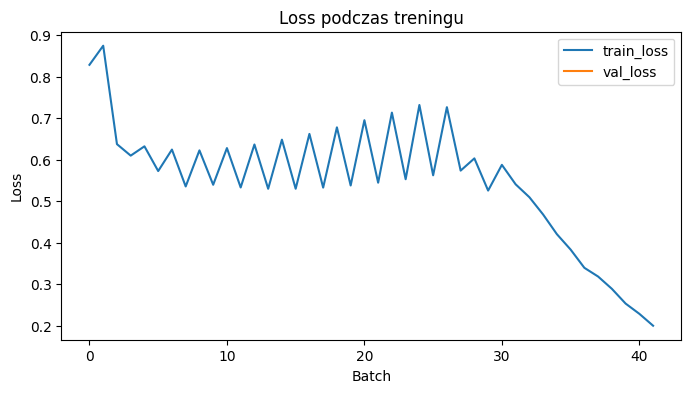

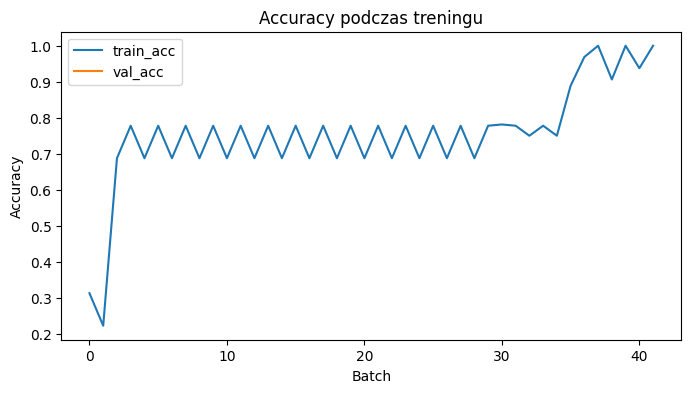

In [31]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,4))
plt.plot(model.train_loss_history, label="train_loss")
plt.plot(model.val_loss_history, label="val_loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Loss podczas treningu")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,4))
plt.plot(model.train_acc_history, label="train_acc")
plt.plot(model.val_acc_history, label="val_acc")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Accuracy podczas treningu")
plt.legend()
plt.show()


In [49]:
import torch_tensorrt

# Wczytanie modelu
model_int8 = LitResNet(num_classes=NUM_CLASSES, qat=True)
model_int8.load_state_dict(torch.load("int8_model.pth"))
model_int8.eval().cuda()

# Kompilacja z TensorRT
trt_model = torch_tensorrt.compile(
    model_int8,
    inputs=[torch_tensorrt.Input((1, 3, 224, 224))],
    enabled_precisions={torch.int8},  # INT8
    workspace_size=1 << 20
)

# Test inference
x = torch.randn(1, 3, 224, 224).cuda()
with torch.no_grad():
    y = trt_model(x)
print(y)


ModuleNotFoundError: No module named 'torch_tensorrt'

In [2]:
!pip install tensorrt

  Using cached tensorrt-10.14.1.48.post1-py2.py3-none-any.whl
  Using cached tensorrt_cu13-10.14.1.48.post1-py2.py3-none-any.whl
  Using cached tensorrt_cu13_libs-10.14.1.48.post1.tar.gz (726 bytes)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tensorrt_cu13_bindings-10.14.1.48.post1-cp310-none-manylinux_2_28_x86_64.whl.metadata (612 bytes)
  Using cached cuda_toolkit-13.1.0-py2.py3-none-any.whl.metadata (9.8 kB)
  Using cached nvidia_cuda_runtime-13.1.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
Using cached tensorrt_cu13_bindings-10.14.1.48.post1-cp310-none-manylinux_2_28_x86_64.whl (879 kB)
Using cached cuda_toolkit-13.1.0-py2.py3-none-any.whl (2.4 kB)
Using cached nvidia_cuda_runtime-13.1.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (2.3 MB)
  Created wheel for tensorrt_cu13_libs: filename=tensorrt_cu13_libs-10.14.1.48.post1-py2.py3-n